In [1]:
import os 
import sys 
import re 
import yaml
import inspect 
import numpy as np 
import pandas as pd
import xarray as xr
from collections import defaultdict
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
pd.set_option('display.max_rows', 400, 'display.min_rows', 400, 'display.max_columns', None)

In [3]:
#get path for USOS_shared directory for correct laptop
#input parameter should be 'CHPC', 'Mac', or 'Windows'
# current_dir = os.path.dirname(os.path.abspath(__file__))
# global_scripts_path = os.path.abspath(os.path.join(current_dir, "..", "global_scripts"))
# sys.path.insert(0,global_scripts_path)
# from dirpath import filepath_source
# dirpath = filepath_source('CHPC')
dirpath = '/uufs/chpc.utah.edu/common/home/haskins-group1/users/vsun/USOS_shared/'

#define path for Hawthorne data directory
savepath= dirpath + 'Hawthorne_data/'

#UDAQ Files
#Verbose file given by Bart
udaq_voc_filepath = dirpath + 'Hawthorne_data/Verbose.csv'
#Quality control file; only has Jul 01 to Aug 01
udaq_qc_voc_filepath = dirpath + 'Hawthorne_data/udaq_QC_07012024_08012024.csv'

In [4]:
#EPA Parameter Codes corresponding to:
#43243: Isoprene
#45201: Benzene
#45202: Toluene
parameter_codes_needed = [43243, 45201, 45202]
voc_species_names = ['Isoprene', 'Benzene', 'Toluene']
usos_voc_species_needed = ['Isoprene_PTR', 'Benzene_PTR', 'Toluene_PTR']

# USOS Files

In [5]:
# load file for all dates of campaign
all_days_filepath = '/uufs/chpc.utah.edu/common/home/haskins-group1/users/vsun/USOS_shared/CampaignData_and_Merges/R0/CSL_MobileLab_Parked/merged/rev_30min/all_CSL_MobileLab_Parked_rev30minv4.nc'
all_days_filepath_load = xr.open_dataset(all_days_filepath)
df_alldays = all_days_filepath_load.to_dataframe()
df_alldays.reset_index(inplace=True)
df_alldays.set_index('time_local', inplace=True, drop=False)

print(df_alldays.columns.values)

['time_UTC' 'O3_ppbv' 'File_Index' 'HONO_CIMS' 'PAN_CIMS' 'APAN_CIMS'
 'PPN_CIMS' 'HCOOH_CIMS' 'jNO2_meas' 'jBrCl' 'jBr2' 'jCCl4' 'jCH2Oa'
 'jCH2Ob' 'jClNO2' 'jClOa' 'jClOb' 'jCl2' 'jHNO2' 'jHNO3' 'jI2' 'jNO2'
 'jNO3a' 'jNO3b' 'jN2O5' 'jO3' 'AOD' 'Altitude_m' 'Course_deg' 'GndSpd_ms'
 'Heading_deg' 'Lat' 'Lon' 'Temp_K' 'RH_percent' 'Pressure_mb'
 'WindDir_deg' 'WindSpd_ms' 'CO2_Piccaro' 'CH4_Piccaro' 'CO_Piccaro'
 'H2O_Piccaro' 'Br2_CIMS' 'BrO_CIMS' 'Cl2_CIMS' 'ClNO2_CIMS' 'BrCl_CIMS'
 'NCl3_CIMS' 'N2O5_CIMS' 'NO_LIF' 'NO2_LIF' 'NOy_LIF' 'Methanol_PTR'
 'Acetonitrile_PTR' 'Acetaldehyde_PTR' 'Ethanol_PTR' 'Methanethiol_PTR'
 'Acrolein_PTR' 'Acetone_Propanal_PTR' 'DMS_PTR' 'Isoprene_PTR'
 'MVK_MACR_PTR' 'Benzene_PTR' 'Toluene_PTR' 'Styrene_PTR'
 'Benzaldehyde_PTR' 'C8Aromatics_PTR' 'C9Aromatics_PTR' 'Naphthalene_PTR'
 'Octanal_PTR' 'Monoterpenes_PTR' 'Nonanal_PTR' 'C7H4ClF3_PTR'
 'D5_siloxane_PTR' 'Acetone_WAS' 'Acrolein_WAS' 'Benzene_WAS' 'C2Cl4_WAS'
 'C2HCl3_WAS' 'CCl4_WAS' 'CF2Cl2_WAS

In [6]:
#to check that the dataframe values came out correctly when reindexing, check original Isoprene PTR vals with cell below
print(df_alldays['Isoprene_PTR'])

time_local
2024-07-14 18:00:00    0.701197
2024-07-14 18:30:00    0.245411
2024-07-14 19:00:00    0.175870
2024-07-14 19:30:00    0.621888
2024-07-14 20:00:00    1.211183
2024-07-14 20:30:00    3.098078
2024-07-14 21:00:00    4.306617
2024-07-14 21:30:00    2.916671
2024-07-14 22:00:00    1.954819
2024-07-14 22:30:00    1.226572
2024-07-14 23:00:00    0.863114
2024-07-14 23:30:00    0.414629
2024-07-15 00:00:00    0.043671
2024-07-15 00:30:00    0.017950
2024-07-15 01:00:00    0.031124
2024-07-15 01:30:00    0.047872
2024-07-15 02:00:00    0.140370
2024-07-15 02:30:00    0.167951
2024-07-15 03:00:00    0.178574
2024-07-15 03:30:00    0.190022
2024-07-15 04:00:00    0.193920
2024-07-15 04:30:00    0.215145
2024-07-15 05:00:00    0.181891
2024-07-15 05:30:00    0.201871
2024-07-15 06:00:00    0.241792
2024-07-15 06:30:00    0.268147
2024-07-15 07:00:00    0.378069
2024-07-15 07:30:00    0.452597
2024-07-15 08:00:00    0.510307
2024-07-15 08:30:00         NaN
2024-07-15 09:00:00         N

In [6]:
#adds padding of NaNs for first day and last day of campaign, since they need to have the same length of time as the other days in order to plot
new_start_time = pd.Timestamp('2024-07-15 00:00:00')
new_end_time = pd.Timestamp('2024-08-18 23:00:00')

# Create a new datetime index from new_start to the end of existing index with same frequency
new_index = pd.date_range(start=new_start_time, end=new_end_time, freq='1h')

# Reindex the dataframe to include new rows
df_alldays = df_alldays.reindex(new_index)
# Now df_expanded has rows starting at 00:00 with NaNs for the new rows

#rename columns
df_alldays = df_alldays.rename(columns={'O3_ppbv':'USOS O3'})

df_usos_species_locate = df_alldays.loc[:,usos_voc_species_needed]
df_usos_species_locate = df_usos_species_locate.rename(columns=dict(zip(usos_voc_species_needed,voc_species_names)))
print(df_usos_species_locate)

                     Isoprene   Benzene   Toluene
2024-07-15 00:00:00  0.043671  0.060633  0.270356
2024-07-15 01:00:00  0.031124  0.233064  0.640997
2024-07-15 02:00:00  0.140370  0.181983  0.664513
2024-07-15 03:00:00  0.178574  0.062843  0.345026
2024-07-15 04:00:00  0.193920  0.088533  0.455622
2024-07-15 05:00:00  0.181891  0.066692  0.369418
2024-07-15 06:00:00  0.241792  0.105605  0.436534
2024-07-15 07:00:00  0.378069  0.183334  0.663779
2024-07-15 08:00:00  0.510307  0.301884  1.087254
2024-07-15 09:00:00       NaN       NaN       NaN
2024-07-15 10:00:00       NaN       NaN       NaN
2024-07-15 11:00:00  0.116184  0.038321  0.379302
2024-07-15 12:00:00  0.160509  0.055968  0.278437
2024-07-15 13:00:00  0.197739  0.030668  0.195716
2024-07-15 14:00:00  0.217583  0.025481  0.207993
2024-07-15 15:00:00  0.189138  0.016608  0.126639
2024-07-15 16:00:00  0.228151  0.013314  0.115069
2024-07-15 17:00:00  0.202450  0.016926  0.119575
2024-07-15 18:00:00  0.246711  0.042242  0.248033


# UDAQ Quality Controlled VOC Measurements file

In [39]:
#Read UDAQ QC VOC measurements file
df_data_qc = pd.read_csv(udaq_qc_voc_filepath) 
#Get only the data at Hawthorne
df_udaq_hawthornedates_usos_only_qc = df_data_qc.loc[(df_data_qc['StationSym'] == 'HW')]
#set index to datetimeindex
df_udaq_hawthornedates_usos_only_qc.set_index(['dt'], inplace = True) 
df_udaq_hawthornedates_usos_only_qc.index = pd.to_datetime(df_udaq_hawthornedates_usos_only_qc.index)

# # #Get only the data during the USOS campaign
df_udaq_hawthornedates_usos_only_qc = df_udaq_hawthornedates_usos_only_qc.sort_index().loc['2024-07-15 00:00:00':'2024-08-18 23:00:00']
# #Change dataframe to the parameters for the species we need
df_udaq_species_needed_qc = df_udaq_hawthornedates_usos_only_qc.loc[df_udaq_hawthornedates_usos_only_qc['Parameter'].isin(parameter_codes_needed)]
#print(df_udaq_species_needed_qc)


#Change the sorting so that we only get the sample value and dateindex, take out unnecessary columns
df_reshaped_udaq_species_qc = df_udaq_species_needed_qc.groupby([df_udaq_species_needed_qc.index, 'Parameter'])['Sample Value'].first().unstack()
df_reshaped_udaq_species_qc = df_reshaped_udaq_species_qc.rename(columns=dict(zip(parameter_codes_needed,voc_species_names)))

/scratch/local/u1545774/7038336/ipykernel_1857330/519825061.py:2: DtypeWarning: Columns (5,14,30) have mixed types. Specify dtype option on import or set low_memory=False.
  df_data_qc = pd.read_csv(udaq_qc_voc_filepath)


In [40]:
display(df_reshaped_udaq_species_qc)

Parameter,Isoprene,Benzene,Toluene
dt,,,
2024-07-15 00:00:00,NaN,NaN,NaN
2024-07-15 01:00:00,NaN,NaN,NaN
2024-07-15 02:00:00,0.4018,1.3678,6.3210
2024-07-15 03:00:00,0.3695,1.2498,5.4564
2024-07-15 04:00:00,0.2952,1.5000,6.7054
2024-07-15 05:00:00,0.3588,1.3383,5.4949
2024-07-15 06:00:00,0.9691,1.2115,4.2181
2024-07-15 07:00:00,2.2987,1.5121,5.1254
2024-07-15 08:00:00,1.3353,0.9103,3.1825


# UDAQ VOC Measurements file, Verbose

In [41]:
#Read UDAQ VOC measurements file
df_data = pd.read_csv(udaq_voc_filepath) 
#Get only the data at Hawthorne
df_udaq_hawthornedates_usos_only = df_data.loc[(df_data['StationSym'] == 'HW')]
#set index to datetimeindex
df_udaq_hawthornedates_usos_only.set_index(['dt'], inplace = True) 
df_udaq_hawthornedates_usos_only.index = pd.to_datetime(df_udaq_hawthornedates_usos_only.index)

#Get only the data during the USOS campaign
df_udaq_hawthornedates_usos_only = df_udaq_hawthornedates_usos_only.sort_index().loc['2024-07-15 00:00:00':'2024-08-18 23:00:00']

#View Parameter code values as only an int (they print with a .0 at the end initially)
df_udaq_hawthornedates_usos_only.Parameter = df_udaq_hawthornedates_usos_only.Parameter.astype(int)

df_udaq_species_needed = df_udaq_hawthornedates_usos_only.loc[df_udaq_hawthornedates_usos_only['Parameter'].isin(parameter_codes_needed)]
df_reshaped_udaq_species = df_udaq_species_needed.groupby([df_udaq_species_needed.index, 'Parameter'])['Sample Value'].first().unstack()
df_reshaped_udaq_species = df_reshaped_udaq_species.rename(columns=dict(zip(parameter_codes_needed,voc_species_names)))

/scratch/local/u1545774/7038336/ipykernel_1857330/1550896121.py:2: DtypeWarning: Columns (14,22,30) have mixed types. Specify dtype option on import or set low_memory=False.
  df_data = pd.read_csv(udaq_voc_filepath)


In [42]:
df_reshaped_udaq_species['Isoprene'] = df_reshaped_udaq_species['Isoprene'] / 5
df_reshaped_udaq_species['Benzene'] = df_reshaped_udaq_species['Benzene'] / 6
df_reshaped_udaq_species['Toluene'] = df_reshaped_udaq_species['Toluene'] / 7

df_reshaped_udaq_species_qc['Isoprene'] = df_reshaped_udaq_species_qc['Isoprene'] / 5
df_reshaped_udaq_species_qc['Benzene'] = df_reshaped_udaq_species_qc['Benzene'] / 6
df_reshaped_udaq_species_qc['Toluene'] = df_reshaped_udaq_species_qc['Toluene'] / 7

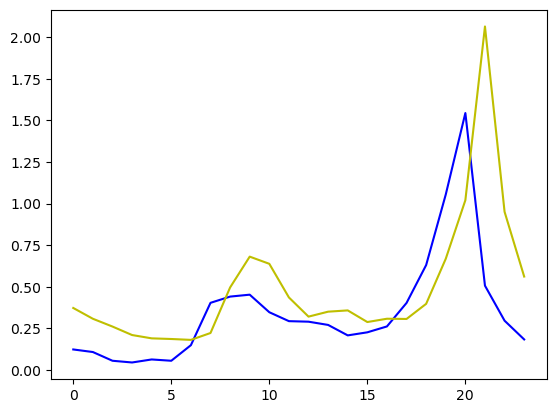

In [44]:

t=df_reshaped_udaq_species_qc.index 
df_reshaped_udaq_species_qc['hour']=t.hour
gb=df_reshaped_udaq_species_qc.groupby(df_reshaped_udaq_species_qc['hour'])['Isoprene'].mean()

tusos = df_usos_species_locate.index
df_usos_species_locate['hour']=tusos.hour
gbusos = df_usos_species_locate.groupby(df_usos_species_locate['hour'])['Isoprene'].mean()

plt.plot(gb.index, gb, color = 'b')
plt.plot(gbusos.index, gbusos, color = 'y')


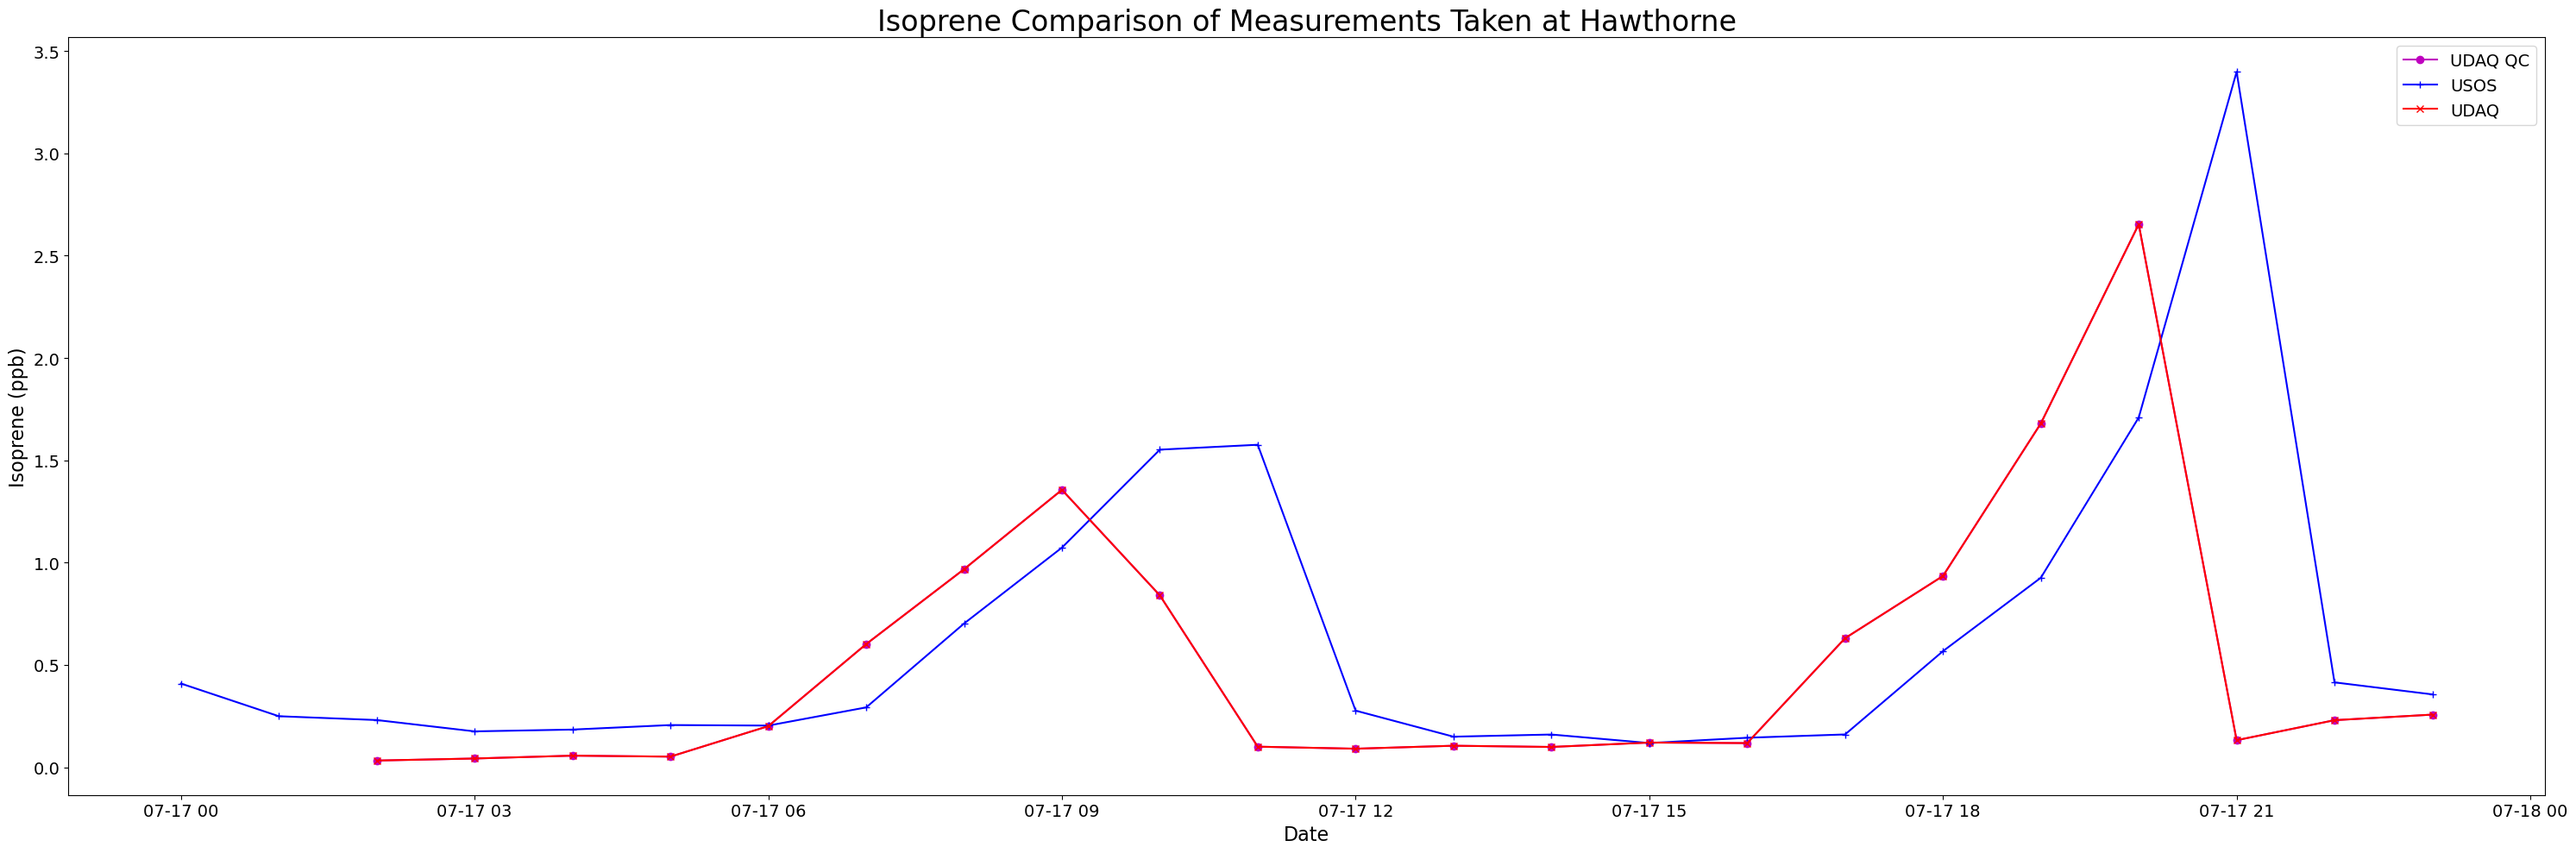

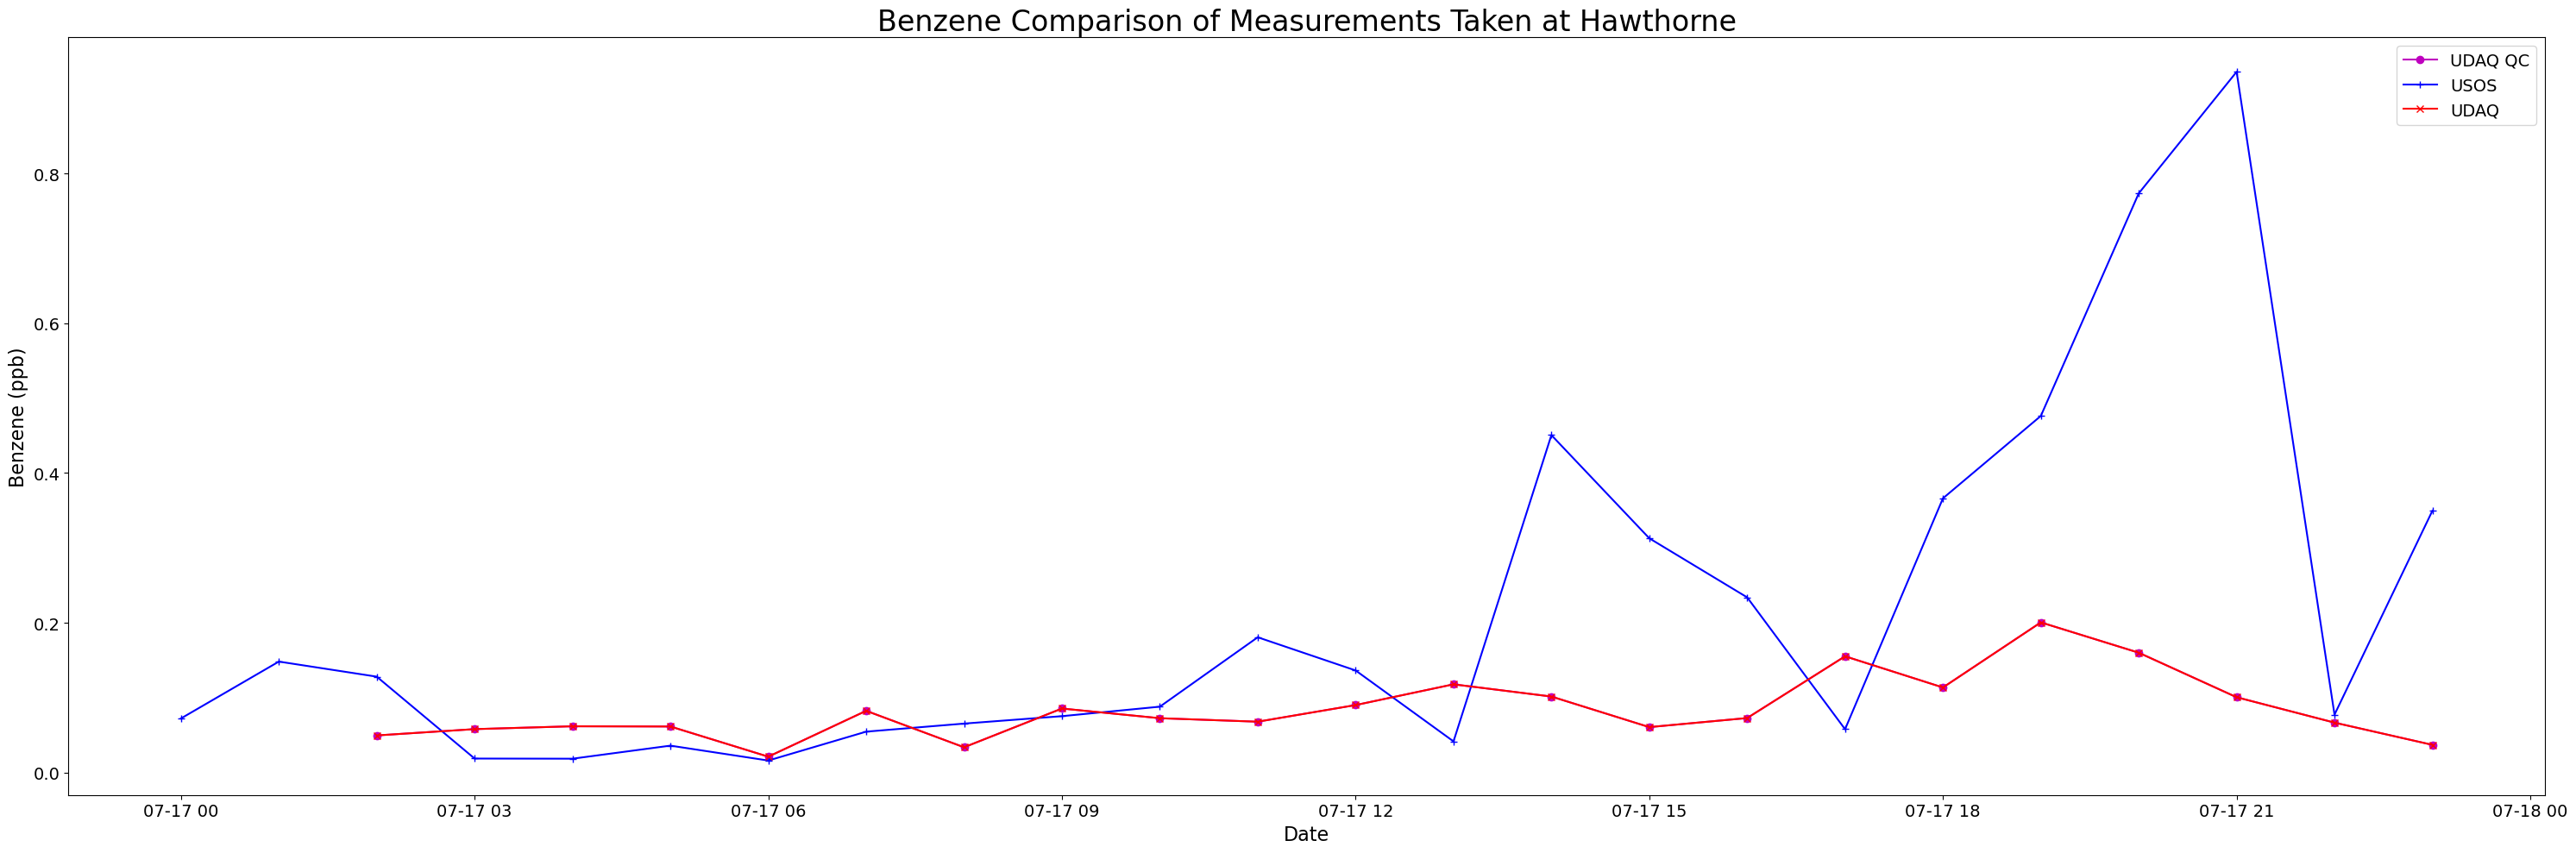

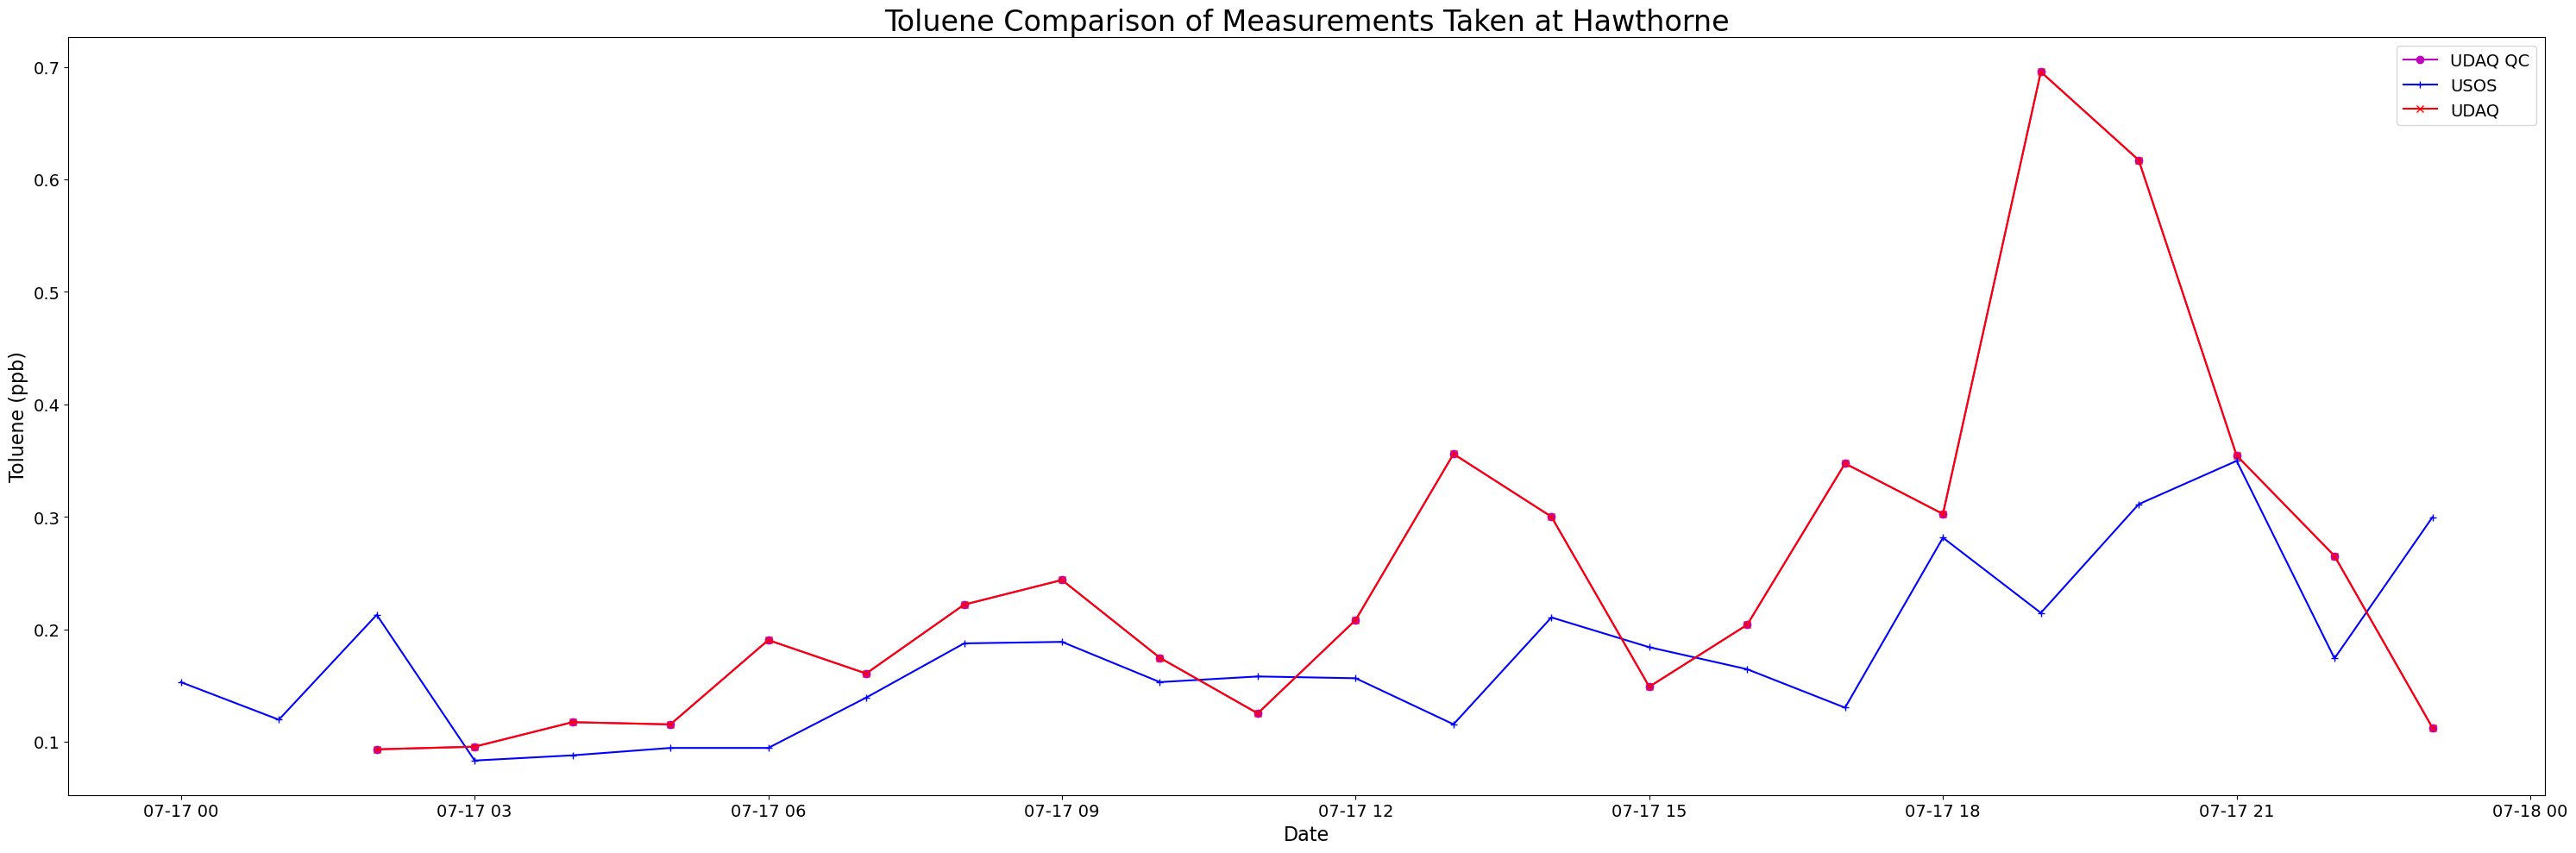

In [47]:
for species in range(0,3):
    # Plot it so we can take a look at it... 
    fig, ax = plt.subplots(figsize = (30,10))
    plt.plot(df_reshaped_udaq_species_qc.index[0+24+24:24+24+24], df_reshaped_udaq_species_qc[voc_species_names[species]][0+24+24:24+24+24], color = 'm', marker = 'o', label = 'UDAQ QC')
    plt.plot(df_usos_species_locate.index[0+24+24:24+24+24], df_usos_species_locate[voc_species_names[species]][0+24+24:24+24+24], color='b', marker='+',label='USOS')
    plt.plot(df_reshaped_udaq_species.index[0+24+24:24+24+24], df_reshaped_udaq_species[voc_species_names[species]][0+24+24:24+24+24], color='r', marker='x', label='UDAQ')
    plt.ylabel(voc_species_names[species] + ' (ppb)', fontsize=16)
    plt.xlabel('Date', fontsize=16)
    plt.legend(fontsize=14)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.title(voc_species_names[species] + ' Comparison of Measurements Taken at Hawthorne', fontsize = 24)
    plt.tight_layout()
    #plt.savefig(dirpath + '/Plotting/USOS_Campaign_analysis/plots/hawthorne_udaq_usos_'+str(voc_species_names[species])+'_comparison.png', dpi =300)
    plt.show()
    # df_reshaped_hawthorne_species.columns.name = None

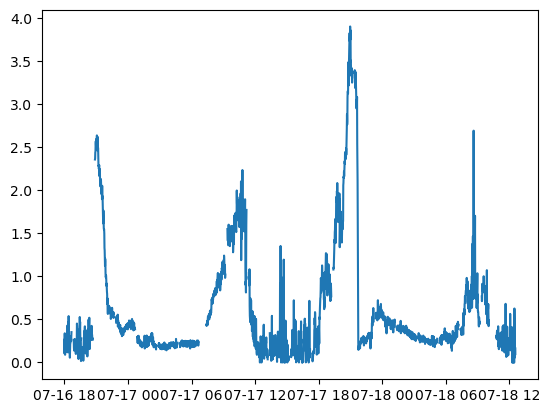

In [54]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Fri Oct 17 14:11:47 2025

@author: u6044586
"""
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from datetime import date 


p1='/uufs/chpc.utah.edu/common/home/haskins-group1/data/Campaign_Data/Raw_Data/USOS_2024/R0/CSL_MobileLab_Parked/20240717/USOS-PTR_MobileLabGround_20240717_RA.ict'
p2='/uufs/chpc.utah.edu/common/home/haskins-group1/data/Campaign_Data/Raw_Data/USOS_2024/R0/CSL_MobileLab_Parked/20240718/USOS-PTR_MobileLabGround_20240718_RA.ict'
files=[p1,p2]

for d,path_i in enumerate(files): 
    with open(path_i) as file:
        lines=file.readlines() 
        
    hd_idx= int(lines[0].split(',')[0].strip())-1

    headers=[h.strip() for h in lines[hd_idx].split(',')]

    if d ==0: 
        data={var: [] for var in headers}

    for ln in range(hd_idx+1, len(lines)): 
        ln=lines[ln].strip() 
        items=ln.split(',') 
        
        for i,var in enumerate(headers): 
            try:
                val=float(items[i])
                if round(val) == -9999:
                    val=np.nan 

                if var==headers[0]: 
                    val=pd.to_timedelta(val, unit='s')+ pd.to_datetime(date(2024, 7, 17+d))- pd.to_timedelta(6, unit='h')

            except ValueError: 
                val= items[i]
            
            data[var]= data[var]+[val]

    


plt.plot(data['Time_Start'], data['C5H8_NOAAPTR_ppbv'])



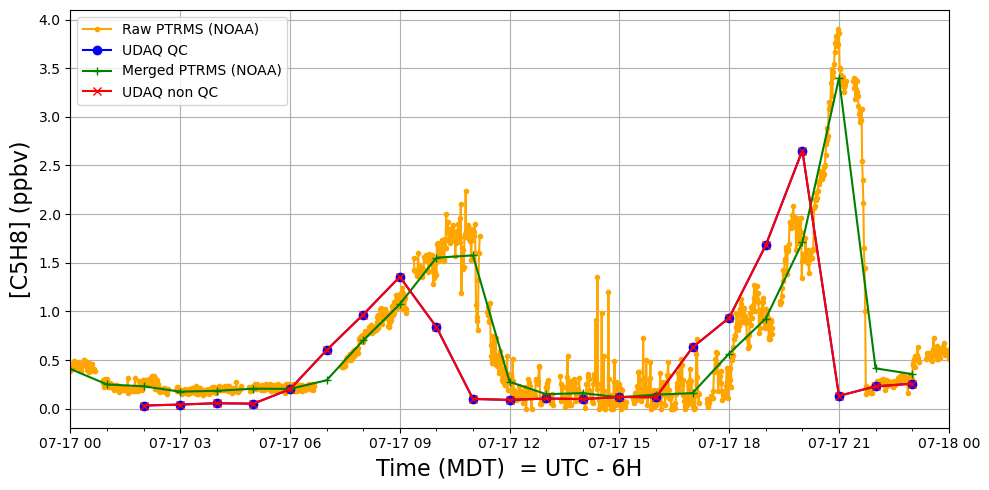

In [75]:
from datetime import datetime

fig, ax = plt.subplots(figsize = (10,5))

plt.plot(data['Time_Start'], data['C5H8_NOAAPTR_ppbv'], marker='.', color='orange', label= 'Raw PTRMS (NOAA)')

plt.plot(df_reshaped_udaq_species_qc.index[0+24+24:24+24+24], 
df_reshaped_udaq_species_qc[voc_species_names[0]][0+24+24:24+24+24], color = 'b', marker = 'o', label = 'UDAQ QC')
plt.plot(df_usos_species_locate.index[0+24+24:24+24+24], df_usos_species_locate[voc_species_names[0]][0+24+24:24+24+24], 
color='g', marker='+',label='Merged PTRMS (NOAA)')
plt.plot(df_reshaped_udaq_species.index[0+24+24:24+24+24], 
df_reshaped_udaq_species[voc_species_names[0]][0+24+24:24+24+24], color='r', marker='x', label='UDAQ non QC')

ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
ax.xaxis.set_minor_locator(mdates.HourLocator(interval=1))
ax.grid(True)
ax.legend() 

ax.set_xlim(datetime(2024,7,17,0,0,0), datetime(2024,7,18,0,0,0))
ax.set_xlabel('Time (MDT)  = UTC - 6H', fontsize=16)
ax.set_ylabel('[C5H8] (ppbv)', fontsize=16)
plt.tight_layout()
plt.savefig(dirpath + '/Plotting/USOS_Campaign_analysis/plots/isoprene_comparison.png', dpi =300)


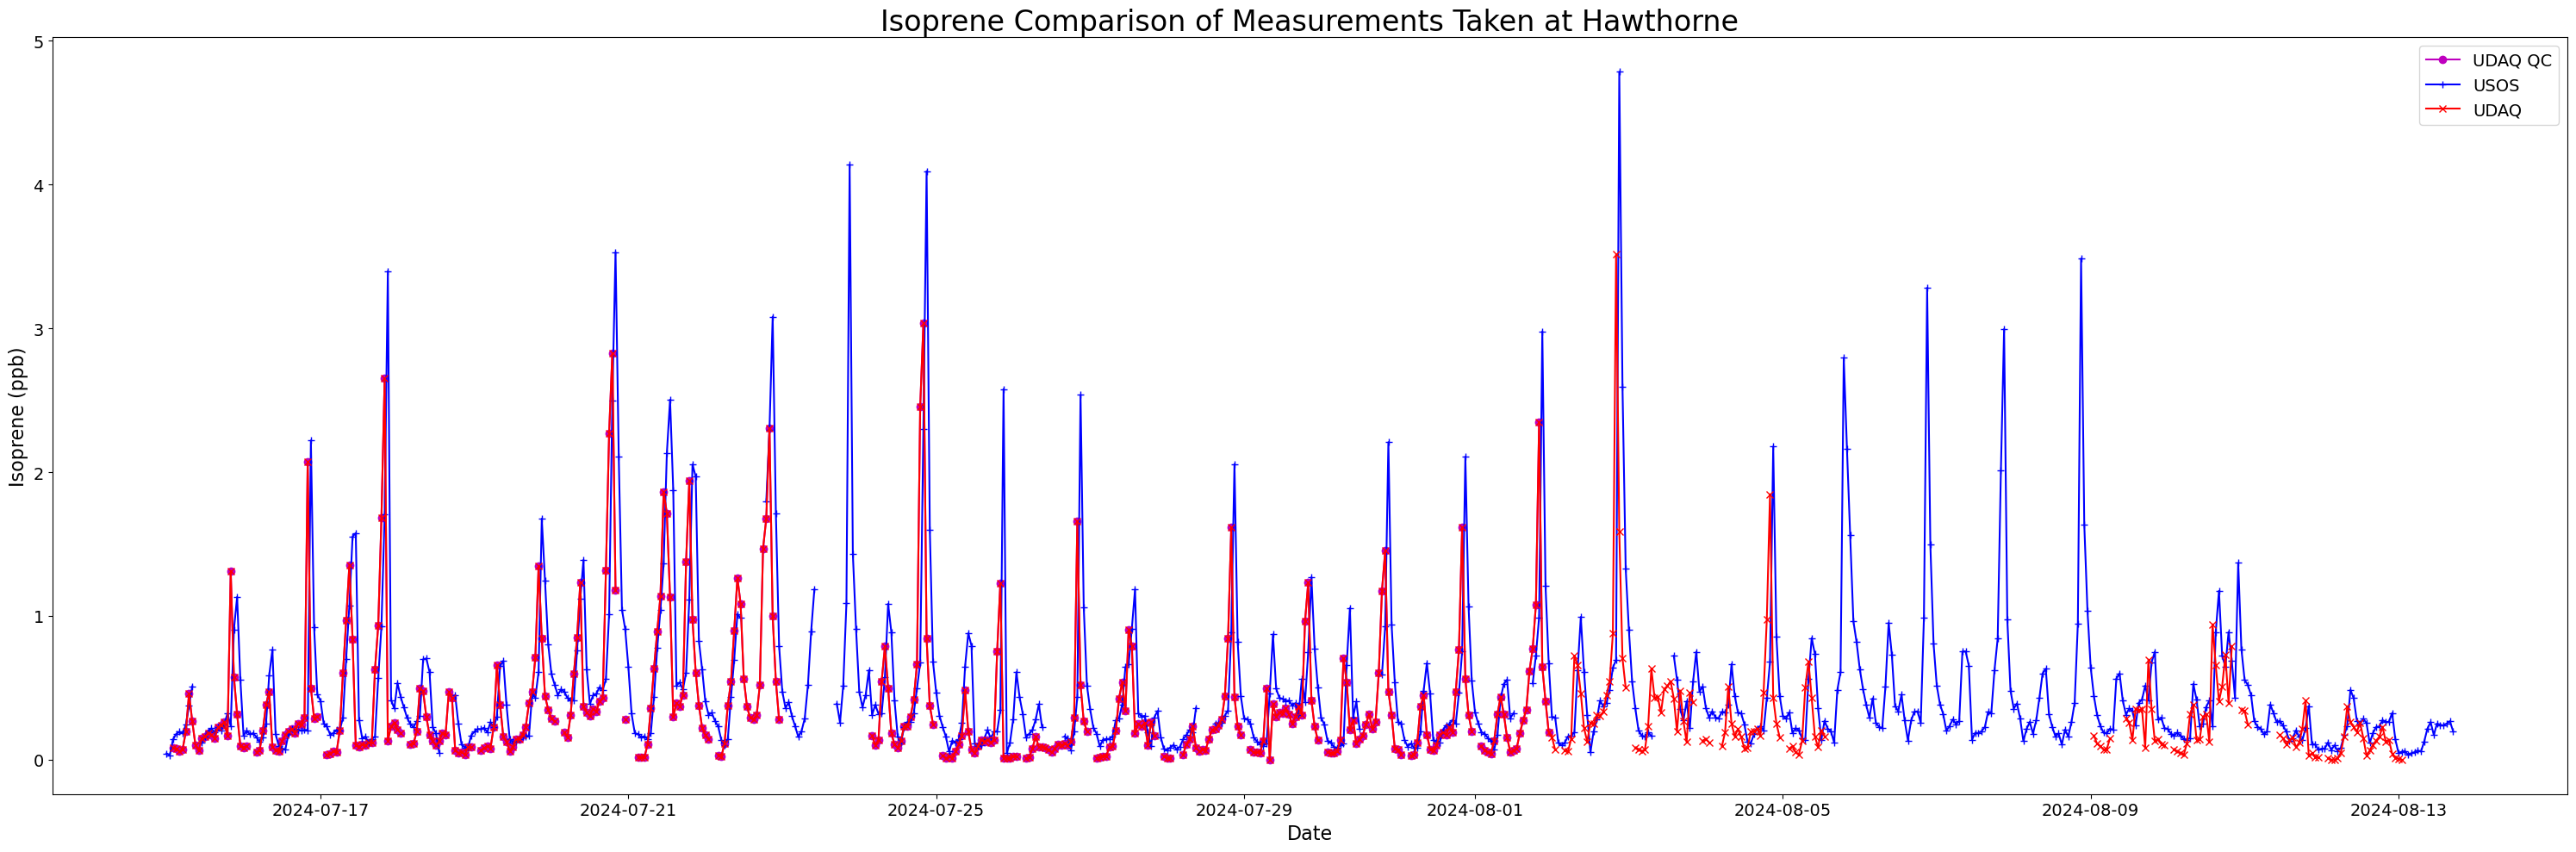

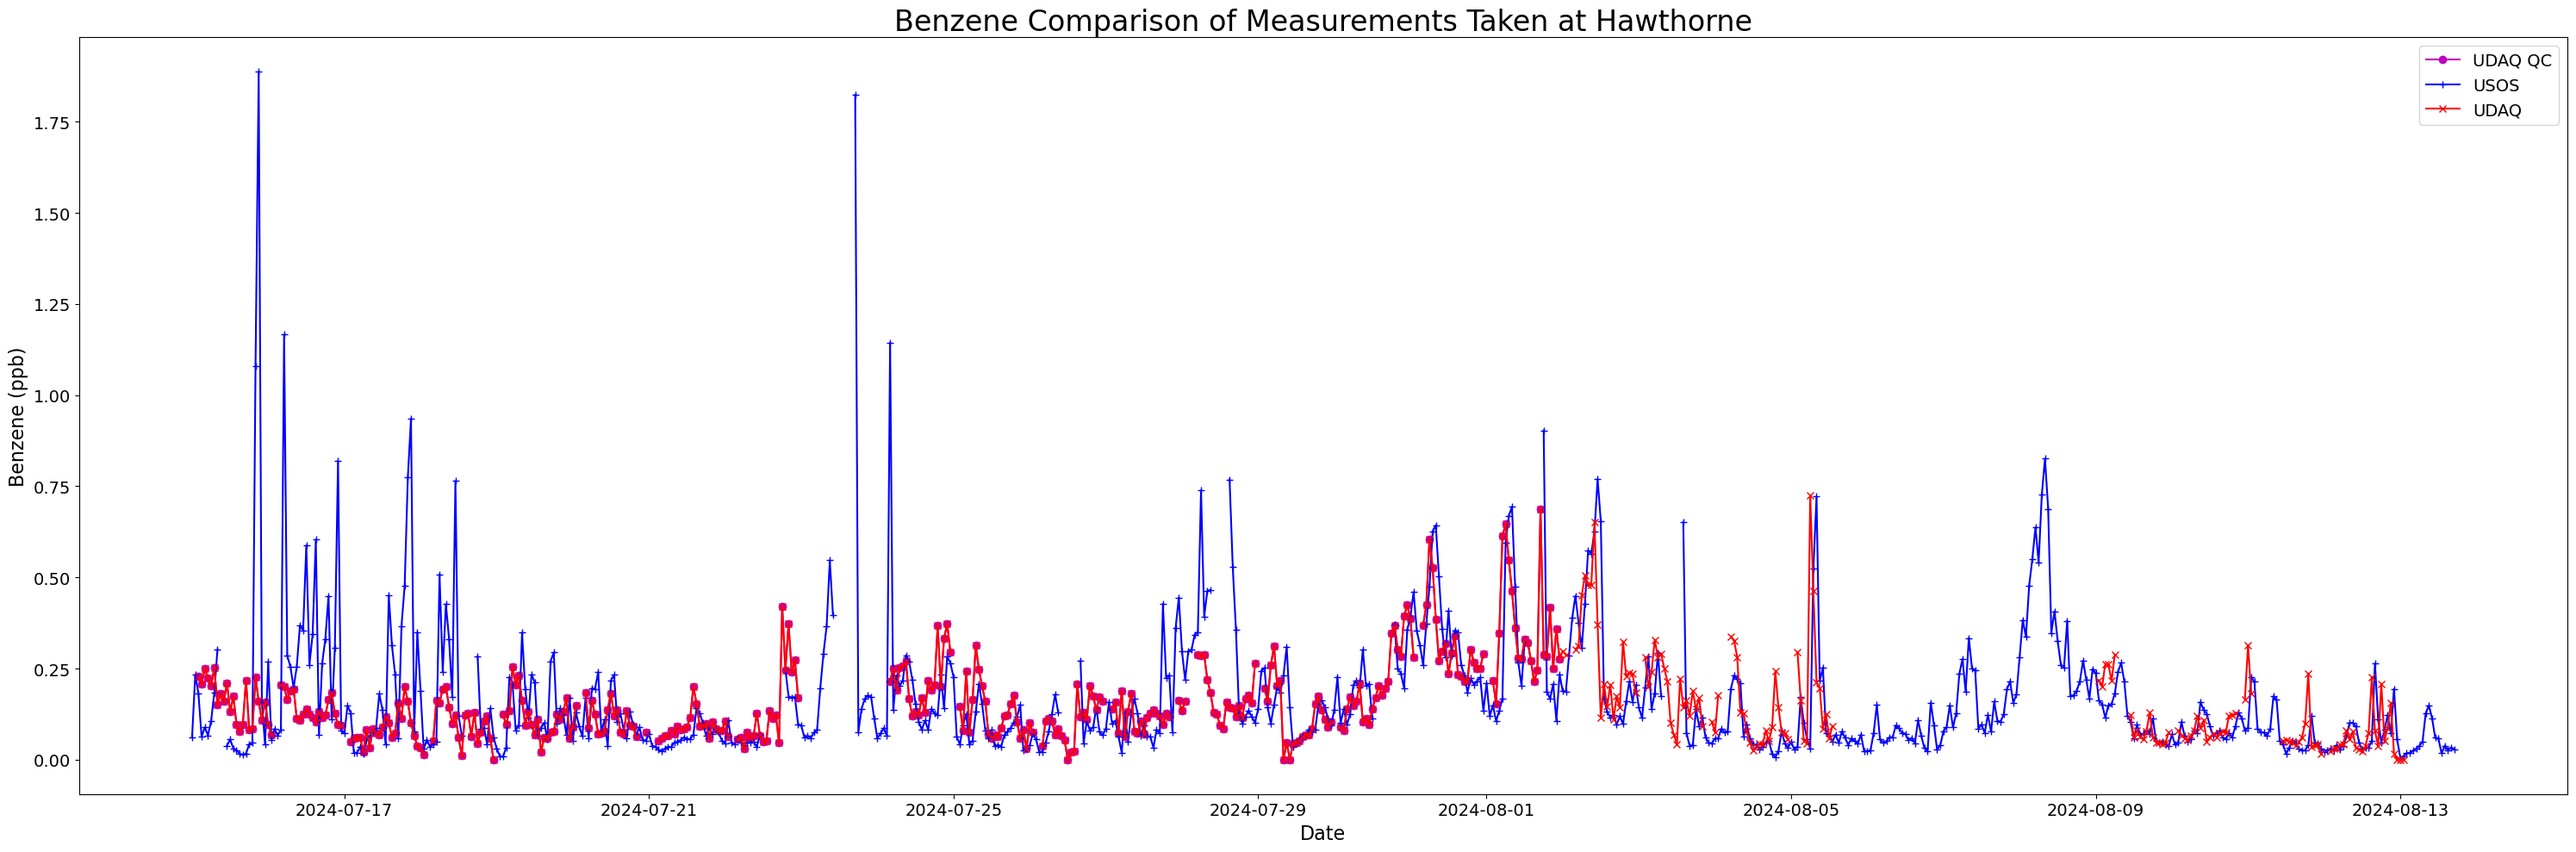

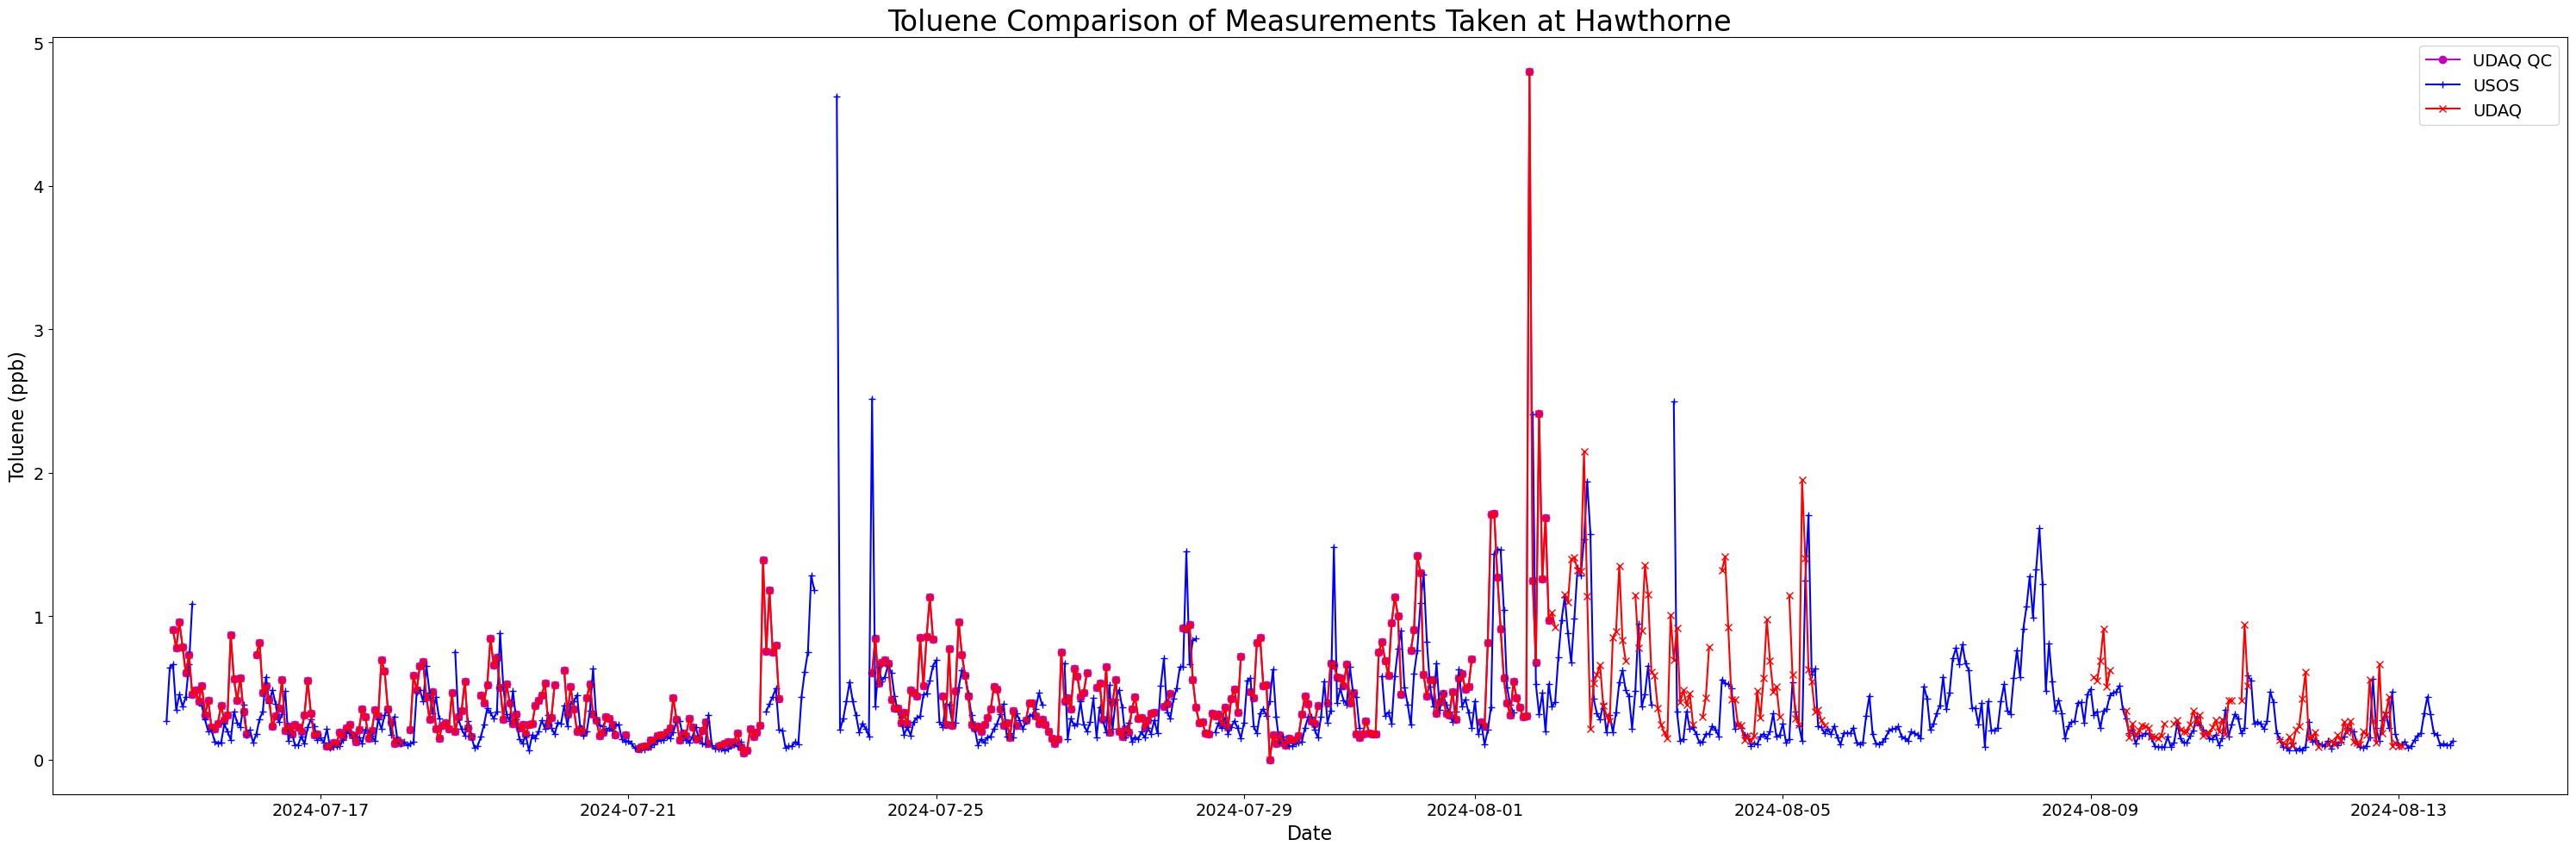

In [28]:
for species in range(0,3):
    # Plot it so we can take a look at it... 
    fig, ax = plt.subplots(figsize = (30,10))
    plt.plot(df_reshaped_udaq_species_qc.index, df_reshaped_udaq_species_qc[voc_species_names[species]], color = 'm', marker = 'o', label = 'UDAQ QC')
    plt.plot(df_usos_species_locate.index, df_usos_species_locate[voc_species_names[species]], color='b', marker='+',label='USOS')
    plt.plot(df_reshaped_udaq_species.index, df_reshaped_udaq_species[voc_species_names[species]], color='r', marker='x', label='UDAQ')
    plt.ylabel(voc_species_names[species] + ' (ppb)', fontsize=16)
    plt.xlabel('Date', fontsize=16)
    plt.legend(fontsize=14)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.title(voc_species_names[species] + ' Comparison of Measurements Taken at Hawthorne', fontsize = 24)
    plt.tight_layout()
    plt.savefig(dirpath + '/Plotting/USOS_Campaign_analysis/plots/hawthorne_udaq_usos_'+str(voc_species_names[species])+'_comparison.png', dpi =300)
    plt.show()
    # df_reshaped_hawthorne_species.columns.name = None

---

# Ozone Comparison

## UDAQ Ozone Measurements

In [12]:
dirpath = '/uufs/chpc.utah.edu/common/home/haskins-group1/users/vsun/USOS_shared/'

udaq_o3_filepath = dirpath + 'Hawthorne_data/hawthorne_udaq_o3_2024.csv'
df_udaq_o3_load = pd.read_csv(udaq_o3_filepath, index_col = 'Date')

index_series = pd.Series(df_udaq_o3_load.index)
index_fixed = index_series.apply(lambda x: x if ':' in x else f'{x} 00:00')
df_udaq_o3_load.index = pd.to_datetime(index_fixed, format='%m/%d/%Y %H:%M')

df_udaq_o3_load = df_udaq_o3_load.rename(columns = {'O3':'UDAQ O3'})
df_udaq_o3_load['UDAQ O3'] = df_udaq_o3_load['UDAQ O3']*1000
df_udaq_o3_load['UDAQ O3'] = df_udaq_o3_load['UDAQ O3'].where(df_udaq_o3_load['UDAQ O3'] <= 120)
display(df_udaq_o3_load)

,UDAQ O3
Date,
2024-07-16 00:00:00,46.0
2024-07-16 01:00:00,53.0
2024-07-16 02:00:00,50.0
2024-07-16 03:00:00,46.0
2024-07-16 04:00:00,41.0
2024-07-16 05:00:00,38.0
2024-07-16 06:00:00,37.0
2024-07-16 07:00:00,33.0
2024-07-16 08:00:00,44.0


In [13]:
df_ozone = pd.concat([df_alldays['USOS O3'], df_udaq_o3_load['UDAQ O3']], axis=1)
#Combine the USOS and UDAQ measurements into merged_ozone column, preferentially filling with USOS vals
df_ozone['merged_ozone'] = df_ozone['USOS O3'].combine_first(df_ozone['UDAQ O3'])
display(df_ozone)

,USOS O3,UDAQ O3,merged_ozone
2024-07-15 00:00:00,NaN,NaN,NaN
2024-07-15 01:00:00,NaN,NaN,NaN
2024-07-15 02:00:00,NaN,NaN,NaN
2024-07-15 03:00:00,NaN,NaN,NaN
2024-07-15 04:00:00,NaN,NaN,NaN
2024-07-15 05:00:00,NaN,NaN,NaN
2024-07-15 06:00:00,NaN,NaN,NaN
2024-07-15 07:00:00,NaN,NaN,NaN
2024-07-15 08:00:00,NaN,NaN,NaN
2024-07-15 09:00:00,NaN,NaN,NaN


Text(0.5, 1.0, 'Ozone Comparison')

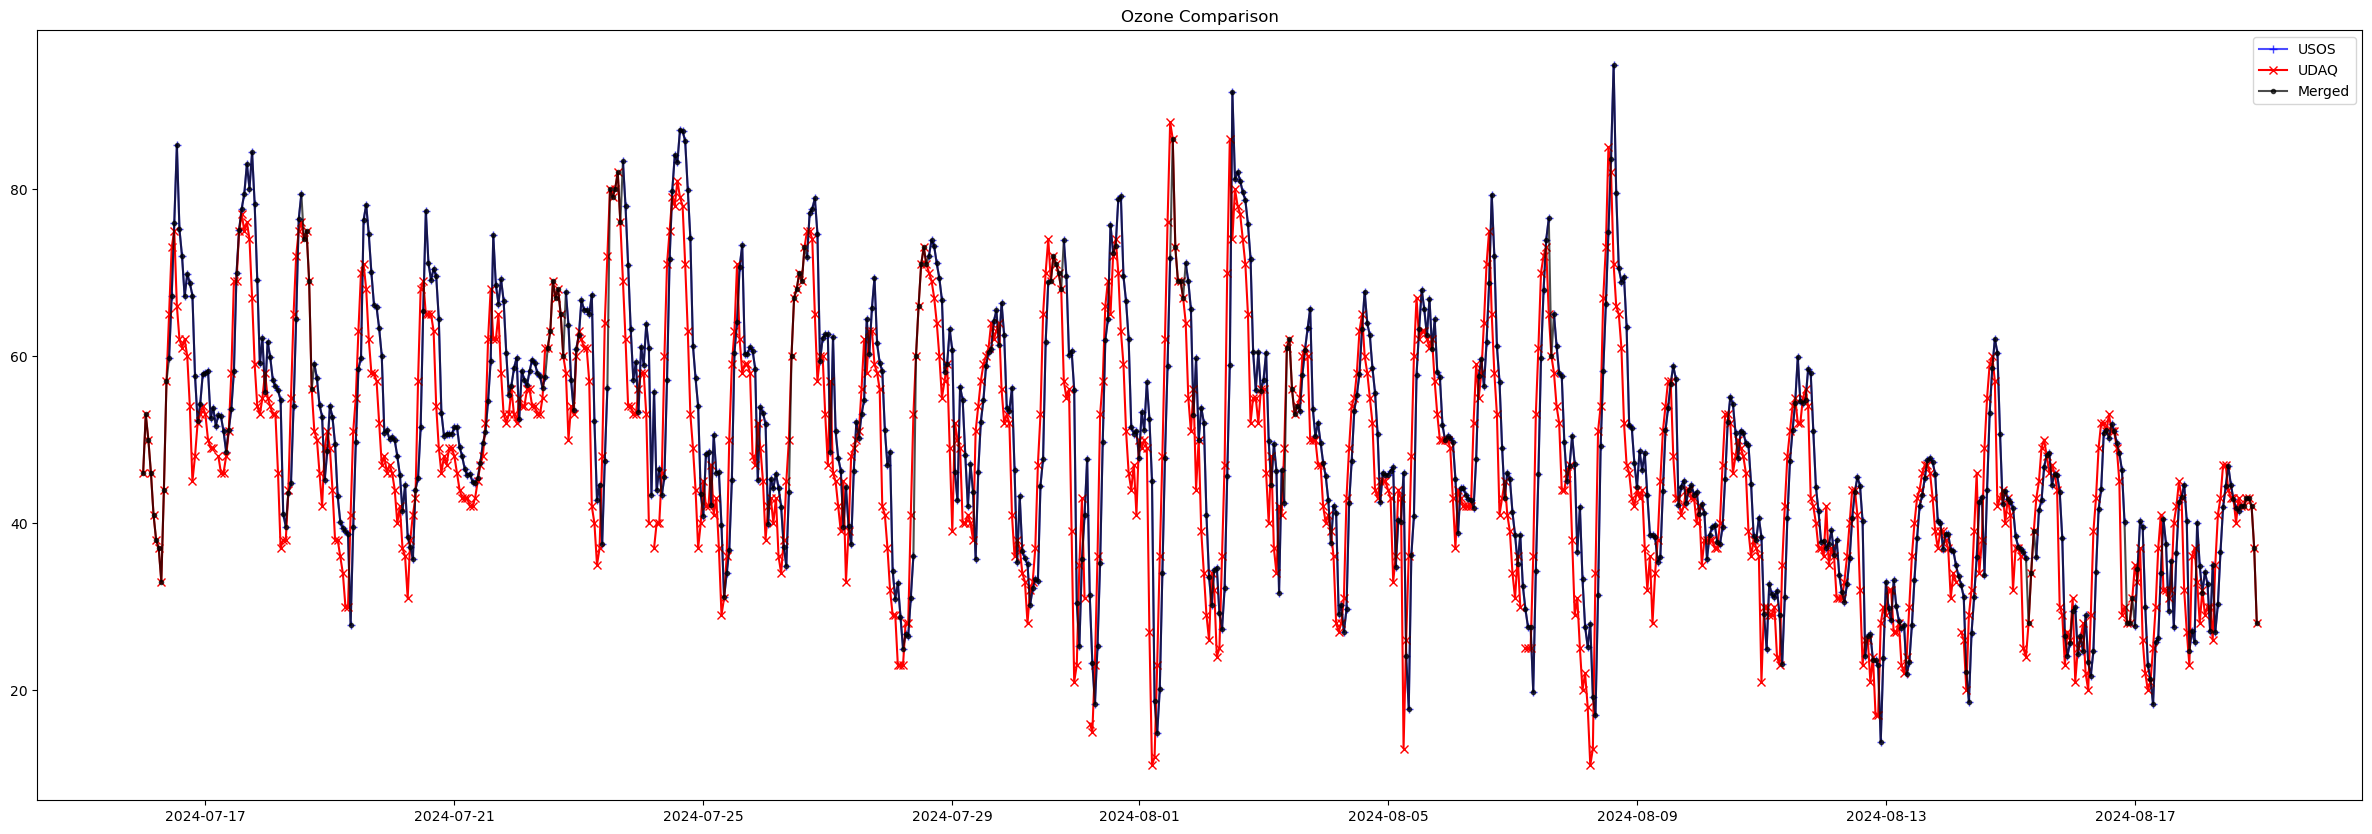

In [14]:
# Plot it so we can take a look at it... 
fig, ax = plt.subplots(figsize = (30,10))
ax.plot(df_ozone.index, df_ozone['USOS O3'], linestyle = 'solid', color='b', marker='+',label='USOS', alpha = 0.7)
ax.plot(df_ozone.index, df_ozone['UDAQ O3'], linestyle = 'solid', color = 'r', marker = 'x', label = 'UDAQ')
ax.plot(df_ozone.index, df_ozone['merged_ozone'], linestyle = 'solid', color='k', marker='.', label='Merged', alpha = 0.7)
plt.legend()
plt.title('Ozone Comparison')

# Exceedances comparison between USOS, UDAQ, combined

In [15]:
for instance in range(0,3):
    # Step 1: Calculate the 8-hour rolling average
    rolling_avg_name = '8hr_rolling_avg_' + df_ozone.columns[instance]
    df_ozone[rolling_avg_name] = df_ozone[df_ozone.columns[instance]].rolling(window=8, min_periods=6).mean()
    #rolling average only works for 8 hours with no gaps; at least 6 hours

    # Step 2: Calculate the maximum 8-hour average for each day
    # Resample to daily frequency, compute the daily max of the rolling averages, drop NA values
    daily_max_8hr_avg_ozone = df_ozone[rolling_avg_name].resample('D').max().dropna()
    #print('Max 8 hr avg each day:\n, adjuststart_daily_max_8hr_avg_ozone)

    # Step 3: Map the daily maximum back to the original dataframe
    # Create a new temporary column with the daily max 8-hour average for each timestamp
    mda8_ozone_name = 'MDA8_O3_' + df_ozone.columns[instance]
    df_ozone[mda8_ozone_name] = df_ozone.index.floor('D').map(daily_max_8hr_avg_ozone)
    print(df_ozone)
    #print('Daily max 8 hour avg for each timestamp: \n', df_adjuststart_hourly_ozone['MDA8_O3'])

    # # Select daytime values only where MD8A > 70
    # df_ozone_day_exceedance_usos = df_ozone[(df_ozone.index.hour >=7) & (df_ozone.index.hour<=20) & (df_ozone['MDA8_O3_USOS O3']>=70)]
    # df_ozone_day_exceedance_udaq = df_ozone[(df_ozone.index.hour >=7) & (df_ozone.index.hour<=20) & (df_ozone['MDA8_O3_UDAQ O3']>=70)]
    # df_ozone_day_exceedance_filled = df_ozone[(df_ozone.index.hour >=7) & (df_ozone.index.hour<=20) & (df_ozone['MDA8_O3_merged_ozone']>=70)]
    #print('When is MDA8 > 70?', df_ozone_day_exceedance)
    exceedance_name = 'Exceedance_day_' + df_ozone.columns[instance]
    df_ozone[exceedance_name] = df_ozone[mda8_ozone_name] >= 70


                       USOS O3  UDAQ O3  merged_ozone  \
2024-07-15 00:00:00        NaN      NaN           NaN   
2024-07-15 01:00:00        NaN      NaN           NaN   
2024-07-15 02:00:00        NaN      NaN           NaN   
2024-07-15 03:00:00        NaN      NaN           NaN   
2024-07-15 04:00:00        NaN      NaN           NaN   
2024-07-15 05:00:00        NaN      NaN           NaN   
2024-07-15 06:00:00        NaN      NaN           NaN   
2024-07-15 07:00:00        NaN      NaN           NaN   
2024-07-15 08:00:00        NaN      NaN           NaN   
2024-07-15 09:00:00        NaN      NaN           NaN   
2024-07-15 10:00:00        NaN      NaN           NaN   
2024-07-15 11:00:00        NaN      NaN           NaN   
2024-07-15 12:00:00        NaN      NaN           NaN   
2024-07-15 13:00:00        NaN      NaN           NaN   
2024-07-15 14:00:00        NaN      NaN           NaN   
2024-07-15 15:00:00        NaN      NaN           NaN   
2024-07-15 16:00:00        NaN 

In [16]:
print(df_ozone.columns)

Index(['USOS O3', 'UDAQ O3', 'merged_ozone', '8hr_rolling_avg_USOS O3',
       'MDA8_O3_USOS O3', 'Exceedance_day_USOS O3', '8hr_rolling_avg_UDAQ O3',
       'MDA8_O3_UDAQ O3', 'Exceedance_day_UDAQ O3',
       '8hr_rolling_avg_merged_ozone', 'MDA8_O3_merged_ozone',
       'Exceedance_day_merged_ozone'],
      dtype='object')


ValueError: could not broadcast input array from shape (840,) into shape (1,)

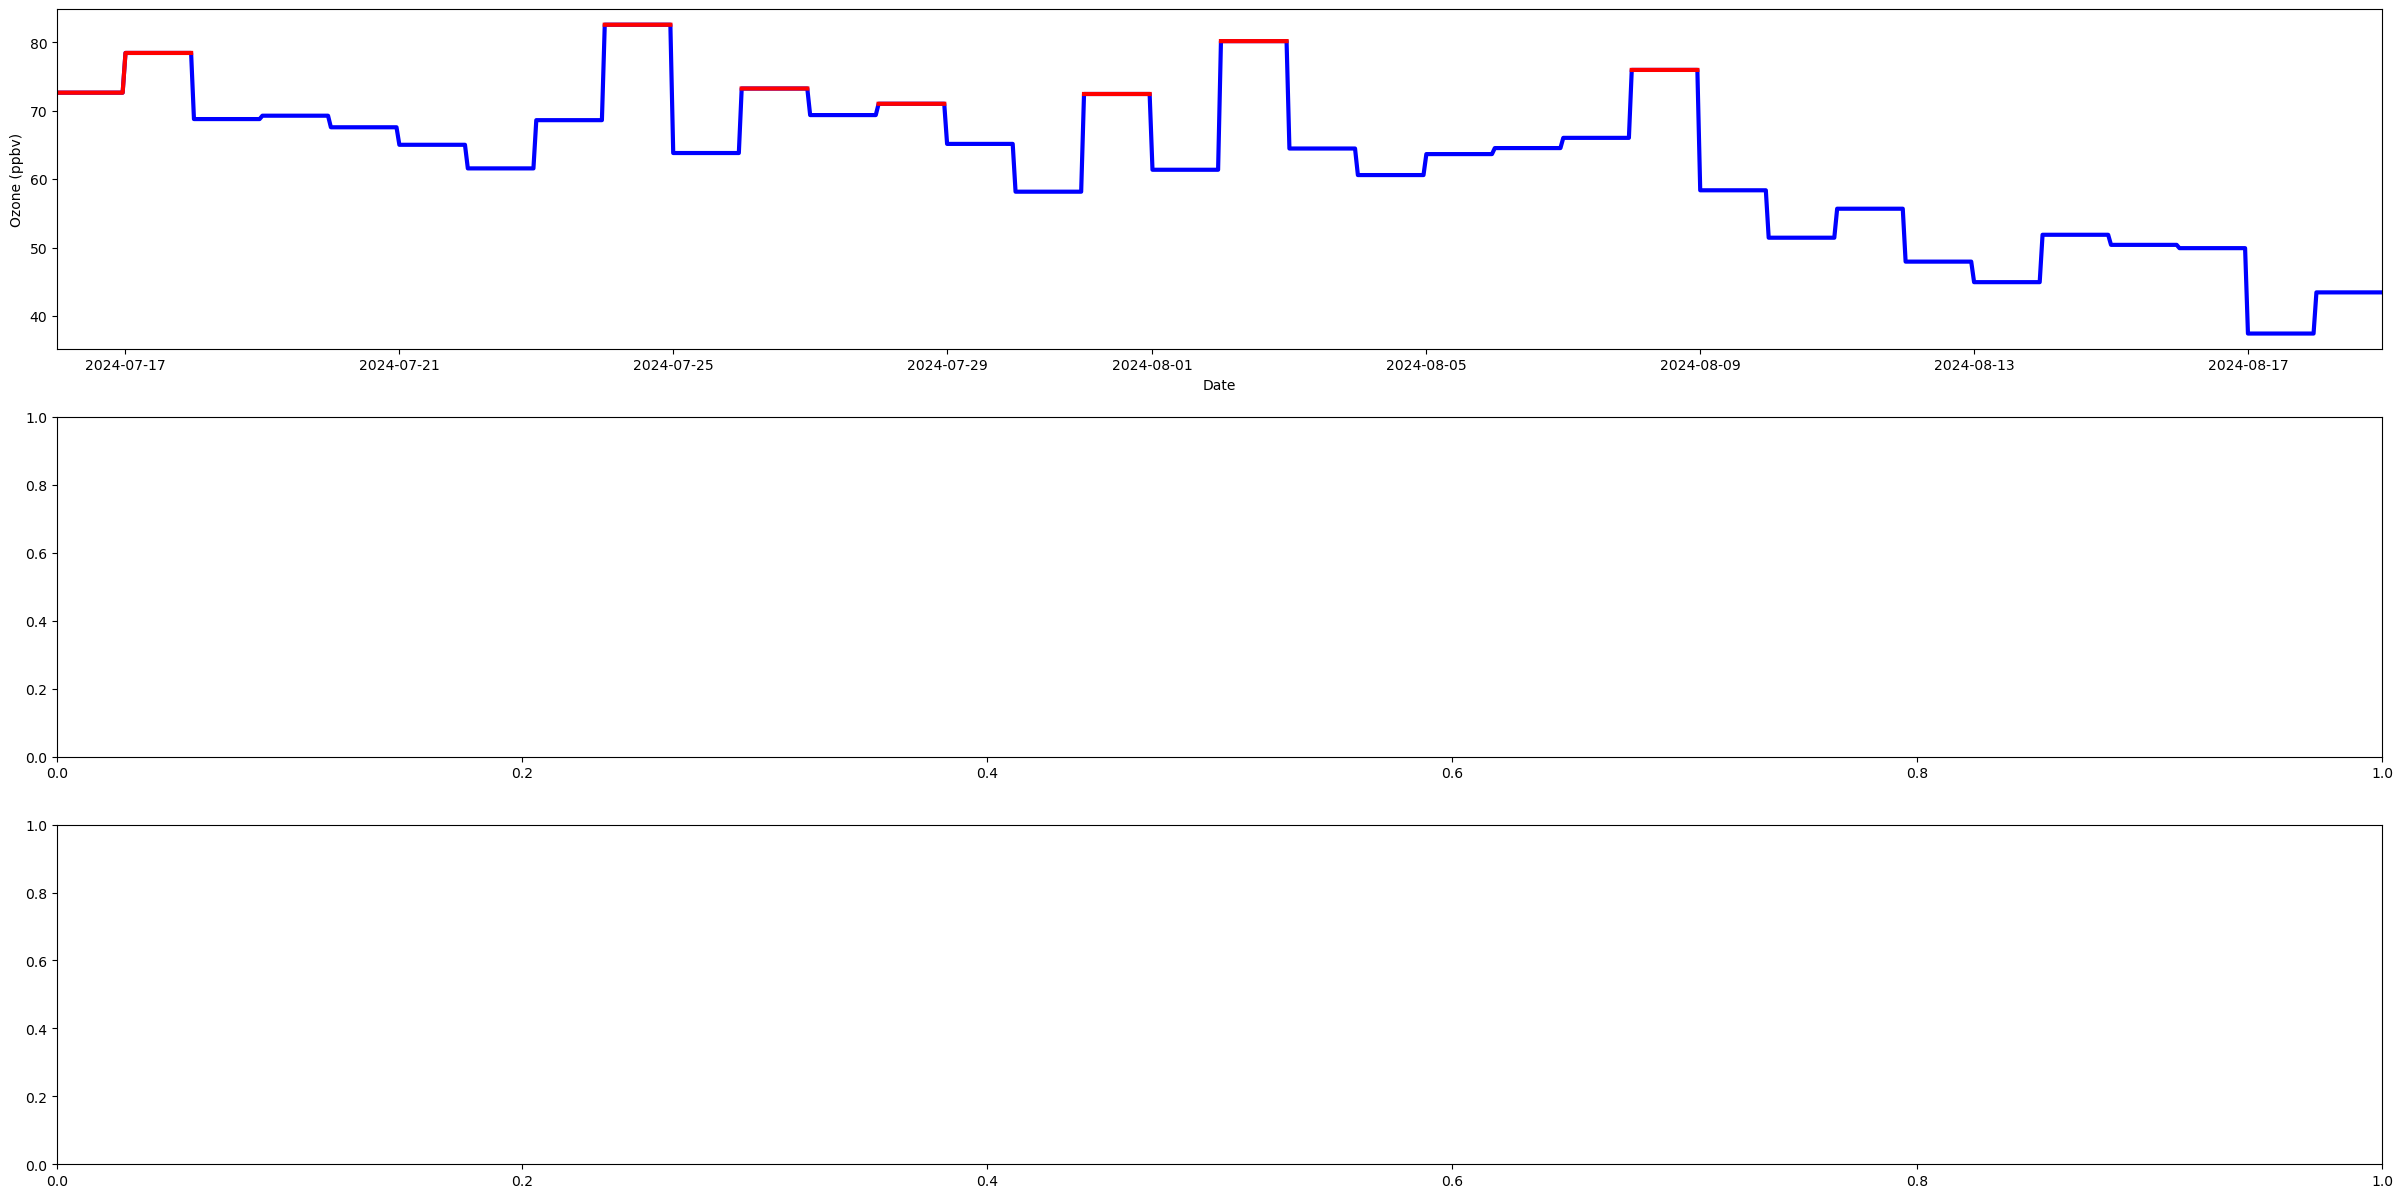

In [17]:
fig, ax = plt.subplots(3,1, figsize = (30,15))
threshold = 70

instance_name = ['USOS', 'UDAQ', 'Merged']
instance_varname = ['USOS O3', 'UDAQ O3', 'merged_ozone']
for instance in range(0,3):
    mda8_ozone_name = 'MDA8_O3_' + df_ozone.columns[instance]
    exceedance_name = 'Exceedance_day_' + df_ozone.columns[instance]
    mda8_exceedance = np.where(df_ozone[mda8_ozone_name].values > threshold, df_ozone[mda8_ozone_name].values , np.nan)
    ax[instance].plot(df_ozone.index, df_ozone[mda8_ozone_name], color='b', linewidth = 3)
    ax[instance].plot(df_ozone.index, mda8_exceedance, color='r', linewidth = 3)
    ax[instance].margins(x=0)
    ax[instance].set_ylabel('Ozone (ppbv)')
    ax[instance].set_xlabel('Date')
    ax[instance].hlines(y=70, xmin = df_ozone.index, xmax = df_ozone.index[len(df_ozone.index)-1], linestyle = 'dashed', color = 'r')
    ax[instance].set_title('MDA8 Ozone for ' + instance_name[instance])

    ax[instance].xaxis.set_major_locator(mdates.DayLocator())
    ax[instance].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

    # Minor ticks: every 6 hours
    ax[instance].xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))

    # Rotate and format tick labels
    ax[instance].tick_params(axis='x', which='major')
    ax[instance].tick_params(axis='x', which='minor', length=4, color='gray')

    # #Set x-axis intervals
    # ozone_ticks = []
    # for ozone_tick_idx in range(48,len(df_ozone.index),6):
    #     ozone_ticks.append(df_ozone.index[ozone_tick_idx])
    # print(ozone_ticks)
    # ax[instance].set_xticks(ozone_ticks)
    # print(daily_max_8hr_avg_ozone.index.strftime('%m/%d'))
    # #ax[instance].set_xticklabels(daily_max_8hr_avg_ozone.index.strftime('%m/%d'))
    # # ax[instance].set_xticks(ticks=ozone_ticks, labels=df_ozone.index.strftime('%m/%d %H%M')[6::6], rotation = 90)
    # # print(df_ozone.index.strftime('%m/%d')[0::24])
    # # ax[instance].set_xticklabels(df_ozone.index.strftime('%m/%d')[0::24])

    midnight_vals = []
    for midnight_idx in range(0,len(df_ozone.index),24):
        midnight_vals.append(df_ozone.index[midnight_idx])
    for day_pos in midnight_vals:
        ax[instance].axvline(day_pos, color = 'black', linestyle = 'dotted', alpha = 0.7)

df_normalized = df_ozone.copy()
df_normalized['date'] = df_ozone.index.normalize()

nan_counts = df_normalized.isna().groupby(df_normalized['date']).sum()


In [ ]:
display(nan_counts)

,USOS O3,UDAQ O3,merged_ozone,8hr_rolling_avg_USOS O3,MDA8_O3_USOS O3,Exceedance_day_USOS O3,8hr_rolling_avg_UDAQ O3,MDA8_O3_UDAQ O3,Exceedance_day_UDAQ O3,8hr_rolling_avg_merged_ozone,MDA8_O3_merged_ozone,Exceedance_day_merged_ozone,date
date,,,,,,,,,,,,,
2024-07-15,24,24,24,24,24,0,24,24,0,24,24,0,0
2024-07-16,10,0,0,15,0,0,5,0,0,5,0,0,0
2024-07-17,0,1,0,0,0,0,0,0,0,0,0,0,0
2024-07-18,4,0,0,7,0,0,0,0,0,0,0,0,0
2024-07-19,0,0,0,0,0,0,0,0,0,0,0,0,0
2024-07-20,0,0,0,0,0,0,0,0,0,0,0,0,0
2024-07-21,0,0,0,0,0,0,0,0,0,0,0,0,0
2024-07-22,7,0,0,10,0,0,0,0,0,0,0,0,0
2024-07-23,5,0,0,8,0,0,0,0,0,0,0,0,0


---

# Compare high ozone days with VOCs

In [ ]:
df_usos_species_locate.index

DatetimeIndex(['2024-07-15 00:00:00', '2024-07-15 01:00:00',
               '2024-07-15 02:00:00', '2024-07-15 03:00:00',
               '2024-07-15 04:00:00', '2024-07-15 05:00:00',
               '2024-07-15 06:00:00', '2024-07-15 07:00:00',
               '2024-07-15 08:00:00', '2024-07-15 09:00:00',
               ...
               '2024-08-18 14:00:00', '2024-08-18 15:00:00',
               '2024-08-18 16:00:00', '2024-08-18 17:00:00',
               '2024-08-18 18:00:00', '2024-08-18 19:00:00',
               '2024-08-18 20:00:00', '2024-08-18 21:00:00',
               '2024-08-18 22:00:00', '2024-08-18 23:00:00'],
              dtype='datetime64[ns]', length=840, freq='h')

In [ ]:
df_ozone.index

DatetimeIndex(['2024-07-15 00:00:00', '2024-07-15 01:00:00',
               '2024-07-15 02:00:00', '2024-07-15 03:00:00',
               '2024-07-15 04:00:00', '2024-07-15 05:00:00',
               '2024-07-15 06:00:00', '2024-07-15 07:00:00',
               '2024-07-15 08:00:00', '2024-07-15 09:00:00',
               ...
               '2024-08-18 14:00:00', '2024-08-18 15:00:00',
               '2024-08-18 16:00:00', '2024-08-18 17:00:00',
               '2024-08-18 18:00:00', '2024-08-18 19:00:00',
               '2024-08-18 20:00:00', '2024-08-18 21:00:00',
               '2024-08-18 22:00:00', '2024-08-18 23:00:00'],
              dtype='datetime64[ns]', length=840, freq='h')

In [ ]:
midnight_all_days = df_ozone.index[df_ozone['Exceedance_day_merged_ozone']==True].normalize().unique().date

midnight_times = pd.to_datetime([f"{date} 00:00:00" for date in midnight_all_days])
last_hr_times = pd.to_datetime([f"{date} 23:00:00" for date in midnight_all_days])
print(midnight_times)
print(last_hr_times)

DatetimeIndex(['2024-07-16', '2024-07-17', '2024-07-23', '2024-07-24',
               '2024-07-26', '2024-07-28', '2024-07-30', '2024-07-31',
               '2024-08-01', '2024-08-02', '2024-08-08'],
              dtype='datetime64[ns]', freq=None)
DatetimeIndex(['2024-07-16 23:00:00', '2024-07-17 23:00:00',
               '2024-07-23 23:00:00', '2024-07-24 23:00:00',
               '2024-07-26 23:00:00', '2024-07-28 23:00:00',
               '2024-07-30 23:00:00', '2024-07-31 23:00:00',
               '2024-08-01 23:00:00', '2024-08-02 23:00:00',
               '2024-08-08 23:00:00'],
              dtype='datetime64[ns]', freq=None)


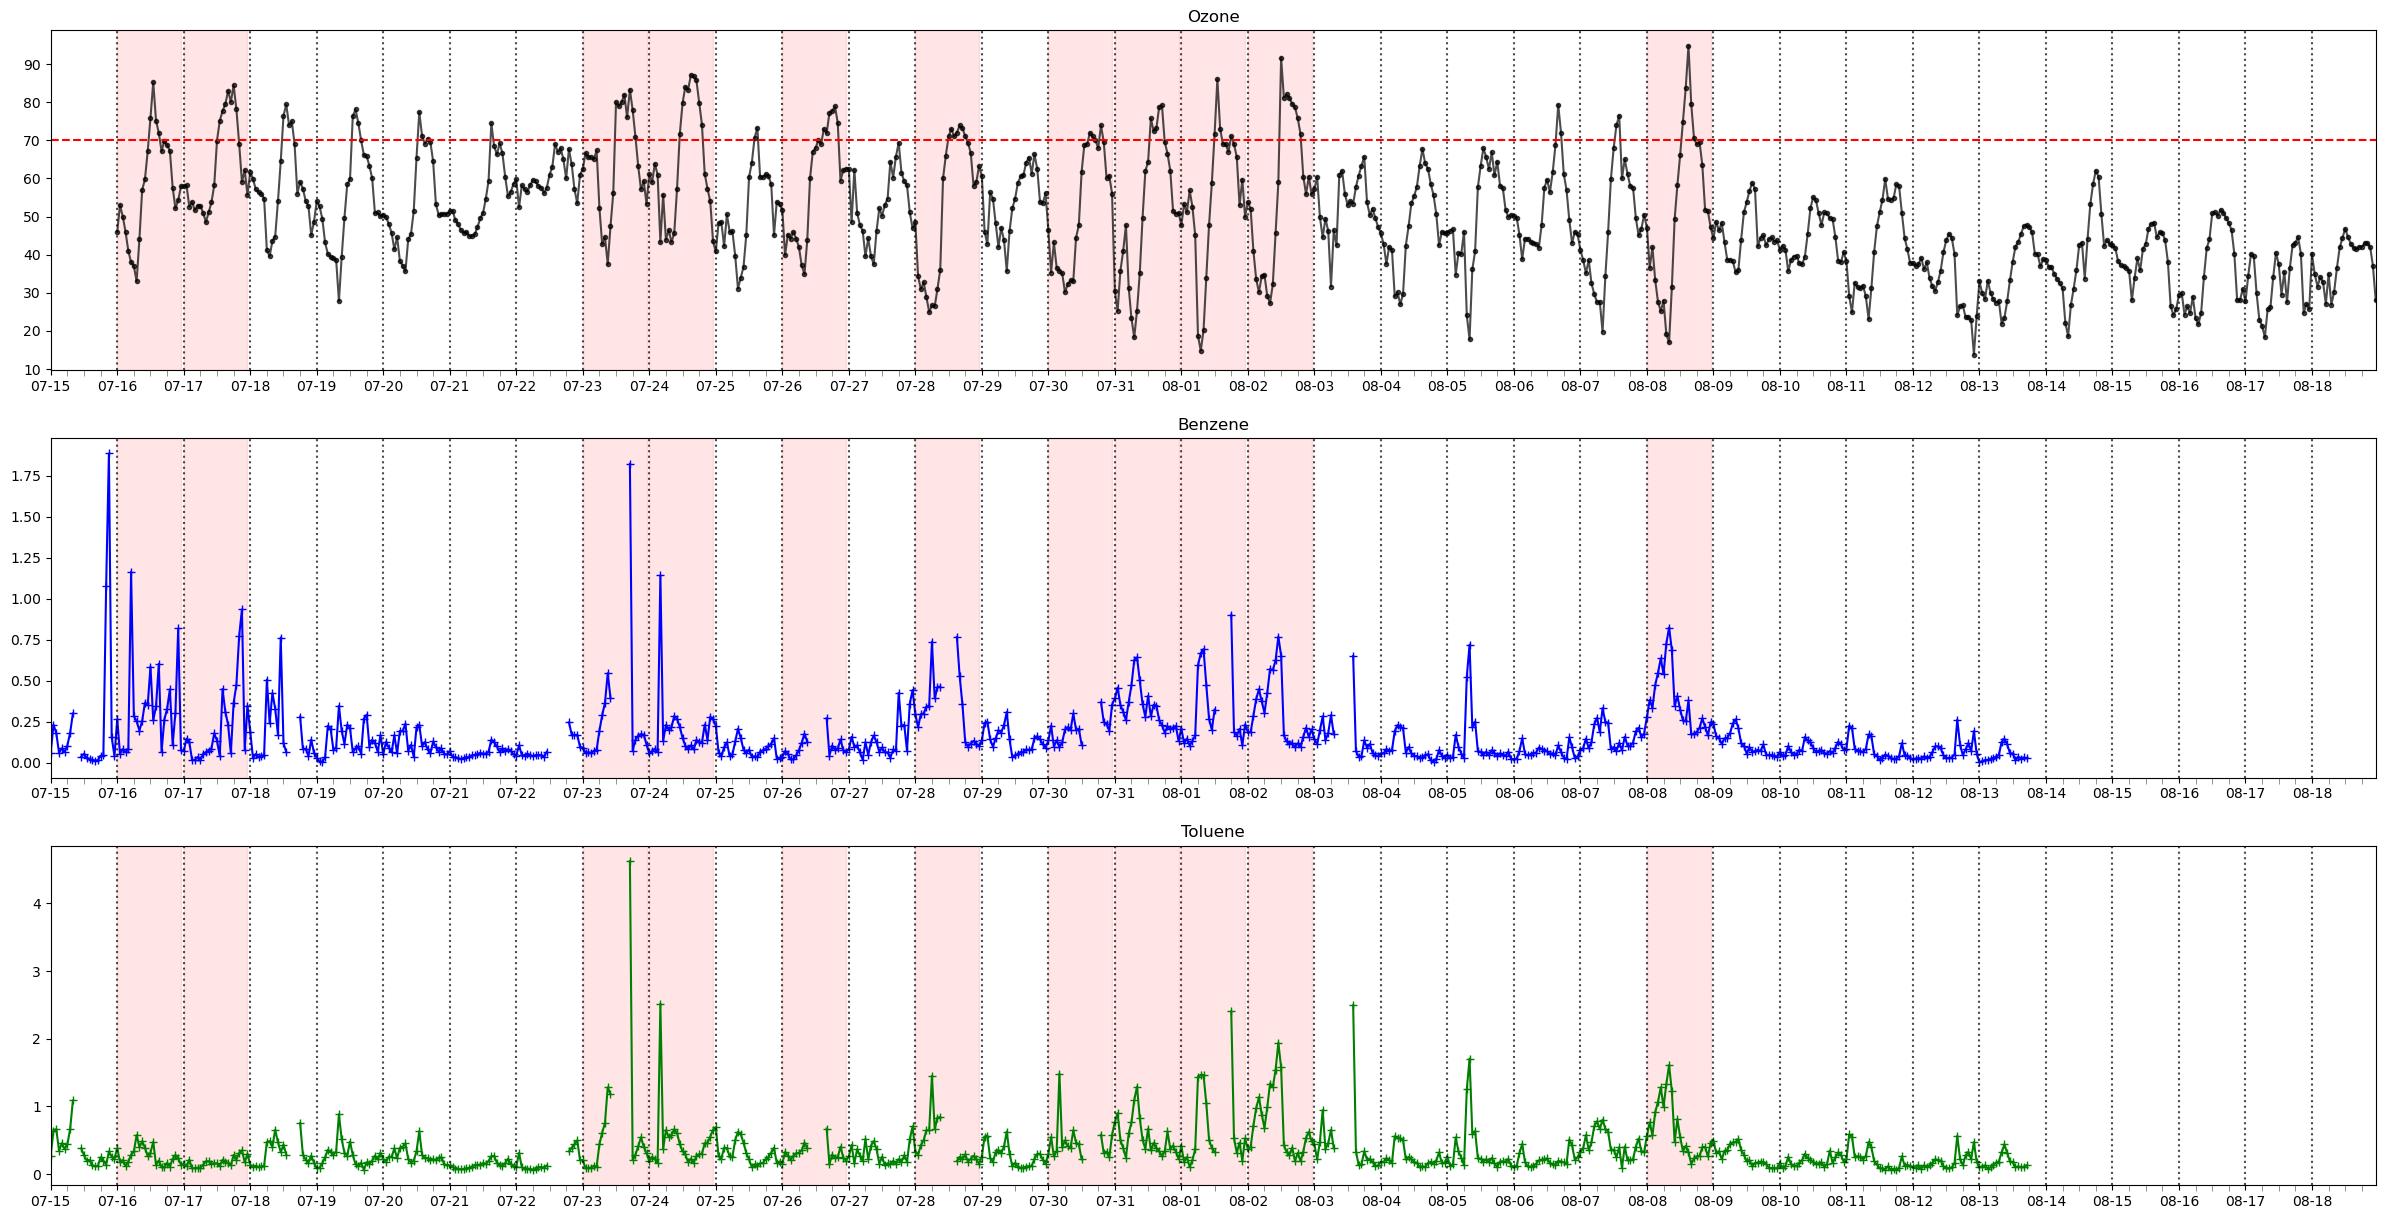

In [ ]:
fig, ax = plt.subplots(3,1, figsize = (30,15), sharex=True)
ax[0].plot(df_ozone.index, df_ozone['merged_ozone'], linestyle = 'solid', color='k', marker='.', label='Merged Ozone', alpha = 0.7)
ax[0].hlines(y=70, xmin = df_ozone.index[0], xmax = df_ozone.index[len(df_ozone.index)-1], linestyle = 'dashed', color = 'r')
#ax[0].set_title('MDA8 Ozone for ' + instance_name[instance])
ax[0].xaxis.set_major_locator(mdates.DayLocator())
ax[0].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
# Minor ticks: every 6 hours
ax[0].xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))
# Rotate and format tick labels
ax[0].tick_params(axis='x', which='major')
ax[0].tick_params(axis='x', which='minor', length=4, color='gray')
midnight_vals = []
for midnight_idx in range(24,len(df_ozone.index),24):
    midnight_vals.append(df_ozone.index[midnight_idx])
for day_pos in midnight_vals:
    ax[0].axvline(day_pos, color = 'black', linestyle = 'dotted', alpha = 0.7)
ax[0].set_title('Ozone')
ax[0].margins(x=0)
ax[0].tick_params(labelbottom=True)

for exceedances in range(0,len(midnight_times)):
    ax[0].axvspan(midnight_times[exceedances], last_hr_times[exceedances], color='red', alpha=0.1)

ax[1].plot(df_usos_species_locate.index, df_usos_species_locate['Benzene'], color='b', marker='+')
ax[1].xaxis.set_major_locator(mdates.DayLocator())
ax[1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
# Minor ticks: every 6 hours
ax[1].xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))
# Rotate and format tick labels
ax[1].tick_params(axis='x', which='major')
ax[1].tick_params(axis='x', which='minor', length=4, color='gray')
midnight_vals = []
for midnight_idx in range(24,len(df_usos_species_locate.index),24):
    midnight_vals.append(df_usos_species_locate.index[midnight_idx])
for day_pos in midnight_vals:
    ax[1].axvline(day_pos, color = 'black', linestyle = 'dotted', alpha = 0.7)
ax[1].set_title('Benzene')
ax[1].margins(x=0)
ax[1].tick_params(labelbottom=True)

for exceedances in range(0,len(midnight_times)):
    ax[1].axvspan(midnight_times[exceedances], last_hr_times[exceedances], color='red', alpha=0.1)

ax[2].plot(df_usos_species_locate.index, df_usos_species_locate['Toluene'], color='g', marker='+')
ax[2].xaxis.set_major_locator(mdates.DayLocator())
ax[2].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
# Minor ticks: every 6 hours
ax[2].xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))
# Rotate and format tick labels
ax[2].tick_params(axis='x', which='major')
ax[2].tick_params(axis='x', which='minor', length=4, color='gray')
midnight_vals = []
for midnight_idx in range(24,len(df_usos_species_locate.index),24):
    midnight_vals.append(df_usos_species_locate.index[midnight_idx])
for day_pos in midnight_vals:
    ax[2].axvline(day_pos, color = 'black', linestyle = 'dotted', alpha = 0.7)
ax[2].set_title('Toluene')
ax[2].margins(x=0)
ax[2].tick_params(labelbottom=True)

for exceedances in range(0,len(midnight_times)):
    ax[2].axvspan(midnight_times[exceedances], last_hr_times[exceedances], color='red', alpha=0.1)

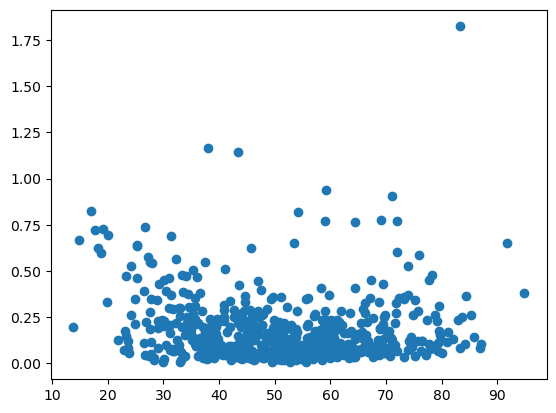

In [ ]:
plt.scatter(df_ozone['merged_ozone'], df_usos_species_locate['Benzene'])

Trying to only get measurements for exceedance days:

In [ ]:
df_ozone['merged_ozone'].loc[midnight_times]

2024-07-16    46.000000
2024-07-17    57.967111
2024-07-23    62.467222
2024-07-24    61.121444
2024-07-26    51.812333
2024-07-28    48.551889
2024-07-30    46.382333
2024-07-31    30.393667
2024-08-01    47.774444
2024-08-02    53.823556
2024-08-08    47.062333
Name: merged_ozone, dtype: float64

In [ ]:
print(df_ozone.index[df_ozone['Exceedance_day_merged_ozone']==True].normalize().unique().date)

[datetime.date(2024, 7, 16) datetime.date(2024, 7, 17)
 datetime.date(2024, 7, 23) datetime.date(2024, 7, 24)
 datetime.date(2024, 7, 26) datetime.date(2024, 7, 28)
 datetime.date(2024, 7, 30) datetime.date(2024, 7, 31)
 datetime.date(2024, 8, 1) datetime.date(2024, 8, 2)
 datetime.date(2024, 8, 8)]


In [ ]:
print(midnight_all_days)

[datetime.date(2024, 7, 16) datetime.date(2024, 7, 17)
 datetime.date(2024, 7, 23) datetime.date(2024, 7, 24)
 datetime.date(2024, 7, 26) datetime.date(2024, 7, 28)
 datetime.date(2024, 7, 30) datetime.date(2024, 7, 31)
 datetime.date(2024, 8, 1) datetime.date(2024, 8, 2)
 datetime.date(2024, 8, 8)]


In [ ]:
for days in range(0, len(midnight_all_days)):
    filtered_days = df_ozone[df_ozone.index.astype('O').isin(midnight_all_days)]

In [ ]:
print(filtered_days)

Empty DataFrame
Columns: [USOS O3, UDAQ O3, merged_ozone, 8hr_rolling_avg_USOS O3, MDA8_O3_USOS O3, Exceedance_day_USOS O3, 8hr_rolling_avg_UDAQ O3, MDA8_O3_UDAQ O3, Exceedance_day_UDAQ O3, 8hr_rolling_avg_merged_ozone, MDA8_O3_merged_ozone, Exceedance_day_merged_ozone]
Index: []


---